# 03 – HRV Calibration Transfer, Sequence Models & Table 5

This notebook reloads the calibration model + scaler from Notebook 02, applies them to WESAD, Empatica, and Fitbit datasets, and produces combined calibrated/uncalibrated predictions for downstream analysis. It also generates scatter plots (Figure 3), trains LSTM and CNN sequence models, produces Table 5 extended metrics, and visualizes confusion matrices.

In [28]:
from pathlib import Path
import pandas as pd

# Force project_root to always be repo base (one level up from notebooks/)
project_root = Path.cwd().resolve()
if project_root.name.lower() == "notebooks":
    project_root = project_root.parent

processed_dir = project_root / "data" / "processed"
results_dir = project_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)

wesad_file = processed_dir / "WESAD_HRV_features.csv"
if not wesad_file.exists():
    raise FileNotFoundError(f"❌ {wesad_file} not found. Run 00 first to generate it.")

wesad = pd.read_csv(wesad_file)

print("✅ Loaded WESAD features from:", wesad_file.resolve())
print("Shape:", wesad.shape)
print("Columns:", wesad.columns.tolist()[:10])


✅ Loaded WESAD features from: C:\Users\Sunil\Projects\HRV-GenAI\data\processed\WESAD_HRV_features.csv
Shape: (45, 38)
Columns: ['HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_SDANN2', 'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5', 'HRV_RMSSD', 'HRV_SDSD']


In [29]:
# =====================================================
# 2. Load calibration model + scaler from Notebook 02
# =====================================================
import joblib
from pathlib import Path

# Ensure results_dir is defined
project_root = Path.cwd().resolve()
if project_root.name.lower() == "notebooks":
    project_root = project_root.parent

results_dir = project_root / "results"

# Load saved calibration artifacts
clf = joblib.load(results_dir / "calibration_model.pkl")
calib_scaler = joblib.load(results_dir / "calibration_scaler.pkl")

print("✅ Loaded calibration model + scaler")


✅ Loaded calibration model + scaler


In [30]:
# =====================================================
# 3. Load datasets + standardize feature names
# =====================================================
import pandas as pd
from pathlib import Path

# Ensure consistent project structure
project_root = Path.cwd().resolve()
if project_root.name.lower() == "notebooks":
    project_root = project_root.parent

processed_dir = project_root / "data" / "processed"
results_dir = project_root / "results"

# Load all processed HRV datasets
wesad     = pd.read_csv(processed_dir / "WESAD_HRV_features.csv")
empatica  = pd.read_csv(processed_dir / "Empatica_HRV_features.csv")
fitbit    = pd.read_csv(processed_dir / "Fitbit_HRV_features.csv")

# Standardize feature names across datasets
rename_map = {
    "MeanHR": "HRV_MeanNN",
    "SDNN": "HRV_SDNN",
    "RMSSD": "HRV_RMSSD",
    "LF": "HRV_LF",
    "HF": "HRV_HF",
    "LF_HF": "HRV_LFHF"
}
empatica = empatica.rename(columns=rename_map)
fitbit   = fitbit.rename(columns=rename_map)

feature_cols = ["HRV_MeanNN", "HRV_SDNN", "HRV_RMSSD", "HRV_LF", "HRV_HF", "HRV_LFHF"]

print("✅ Datasets standardized successfully")
print("📄 WESAD path:", processed_dir / "WESAD_HRV_features.csv")
print("WESAD features:", [c for c in wesad.columns if c in feature_cols])
print("Empatica features:", [c for c in empatica.columns if c in feature_cols])
print("Fitbit features:", [c for c in fitbit.columns if c in feature_cols])


✅ Datasets standardized successfully
📄 WESAD path: C:\Users\Sunil\Projects\HRV-GenAI\data\processed\WESAD_HRV_features.csv
WESAD features: ['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_LF', 'HRV_HF', 'HRV_LFHF']
Empatica features: ['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_LF', 'HRV_HF', 'HRV_LFHF']
Fitbit features: ['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_LF', 'HRV_HF', 'HRV_LFHF']


In [31]:
# =====================================================
# 4. Generate calibrated + uncalibrated predictions
# =====================================================
import numpy as np
import pandas as pd
from pathlib import Path

# Ensure consistent project root and results path
project_root = Path.cwd().resolve()
if project_root.name.lower() == "notebooks":
    project_root = project_root.parent

results_dir = project_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)

# --- Helper function
def generate_predictions(df, dataset_name):
    """
    Generate calibrated and uncalibrated predictions for a given dataset.
    Uses the globally loaded clf, calib_scaler, and feature_cols.
    """
    # If Label column missing (e.g., Empatica/Fitbit), fill with zeros
    if "Label" in df.columns:
        y_true = df["Label"].values
    else:
        y_true = np.zeros(len(df), dtype=int)

    # Apply scaling before calibrated prediction
    X_scaled = calib_scaler.transform(df[feature_cols])

    # Predict calibrated and uncalibrated probabilities
    y_pred_cal = clf.predict_proba(X_scaled)[:, 1]
    y_pred_uncal = clf.predict_proba(df[feature_cols])[:, 1]

    # Return combined dataframe
    return pd.DataFrame({
        "dataset": dataset_name,
        "y_true": y_true,
        "y_pred_cal": y_pred_cal,
        "y_pred_uncal": y_pred_uncal
    })

# --- Run on all datasets
df_all = pd.concat([
    generate_predictions(wesad, "WESAD"),
    generate_predictions(empatica, "Empatica"),
    generate_predictions(fitbit, "Fitbit")
], ignore_index=True)

# --- Save results
out_file = results_dir / "Calibrated_HRV_Predictions_All.csv"
df_all.to_csv(out_file, index=False)

print("✅ Combined predictions saved →", out_file)
print("Dataset counts:\n", df_all['dataset'].value_counts())
display(df_all.head())


✅ Combined predictions saved → C:\Users\Sunil\Projects\HRV-GenAI\results\Calibrated_HRV_Predictions_All.csv
Dataset counts:
 dataset
Fitbit      1007
Empatica     925
WESAD         45
Name: count, dtype: int64


C:\Users\Sunil\Projects\HRV-GenAI\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Sunil\Projects\HRV-GenAI\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Sunil\Projects\HRV-GenAI\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


,dataset,y_true,y_pred_cal,y_pred_uncal
0,WESAD,1,1.983044e-05,0.0
1,WESAD,2,4.847795e-05,0.0
2,WESAD,3,7.411549e-07,0.0
3,WESAD,1,5.094195e-07,0.0
4,WESAD,2,2.034834e-04,0.0


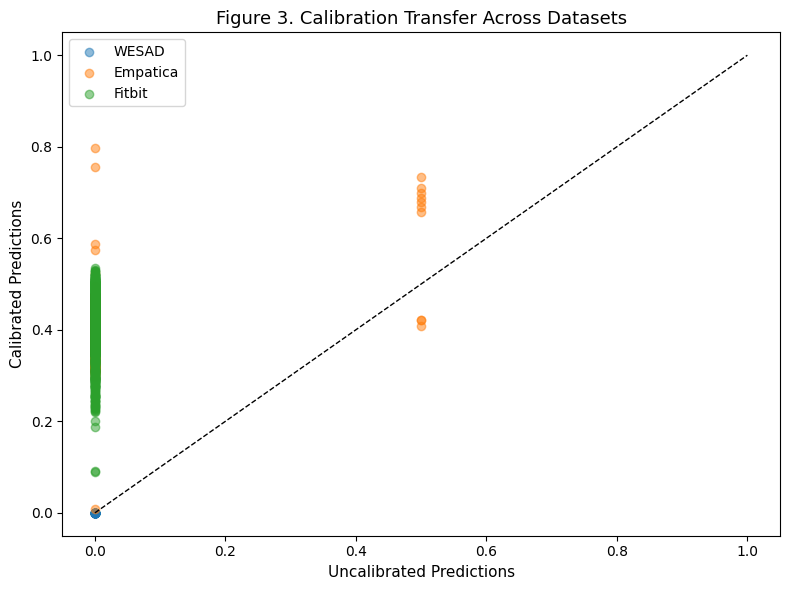

In [32]:
# =====================================================
# 5. Scatter Plot (Figure 3)
# =====================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for ds in ["WESAD", "Empatica", "Fitbit"]:
    subset = df_all[df_all["dataset"] == ds]
    if not subset.empty:
        plt.scatter(
            subset["y_pred_uncal"],
            subset["y_pred_cal"],
            alpha=0.5,
            label=ds
        )

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("Uncalibrated Predictions", fontsize=11)
plt.ylabel("Calibrated Predictions", fontsize=11)
plt.title("Figure 3. Calibration Transfer Across Datasets", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
# =====================================================
# 6. Prepare Sequence Data
# =====================================================
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Extract features and labels
X = wesad[feature_cols].values
y = wesad["Label"].values

# Standardize feature values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create sequential windows (for LSTM/CNN input)
seq_len = 3  # adjustable sequence length
n_samples = X_scaled.shape[0] // seq_len

# Reshape into (samples, timesteps, features)
X_seq = X_scaled[:n_samples * seq_len].reshape((n_samples, seq_len, X_scaled.shape[1]))
y_seq = y[:n_samples * seq_len].reshape((n_samples, seq_len)).max(axis=1)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.3,
    random_state=42,
    stratify=y_seq if len(np.unique(y_seq)) > 1 else None
)

print("✅ Sequence data prepared")
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


✅ Sequence data prepared
Train shape: (10, 3, 6) Test shape: (5, 3, 6)


In [34]:
# =====================================================
# 4. Train LSTM and CNN Models
# =====================================================
import matplotlib.pyplot as plt

# Train LSTM
print("🚀 Training LSTM model...")
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Train CNN
print("\n🚀 Training CNN model...")
history_cnn = cnn_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

print("✅ Training completed for both models")


🚀 Training LSTM model...
Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.0000e+00 - loss: -3.1450 - val_accuracy: 0.0000e+00 - val_loss: -2.3730
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.0000e+00 - loss: -3.2794 - val_accuracy: 0.0000e+00 - val_loss: -2.5192
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.0000e+00 - loss: -3.7360 - val_accuracy: 0.0000e+00 - val_loss: -2.6728
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.0000e+00 - loss: -3.7754 - val_accuracy: 0.0000e+00 - val_loss: -2.8337
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.0000e+00 - loss: -4.0115 - val_accuracy: 0.0000e+00 - val_loss: -3.0025
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.0000e+00 - loss: -4.2395 - val_accuracy: 0.0000e+00 - val_loss: -3.1797
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.0000e+00 - loss: -4.2682 - val_accuracy: 0.0000e+00 - val_loss: -3.3647
Epoch 8/20
1/1 ━━━━━━━━━━━━━━

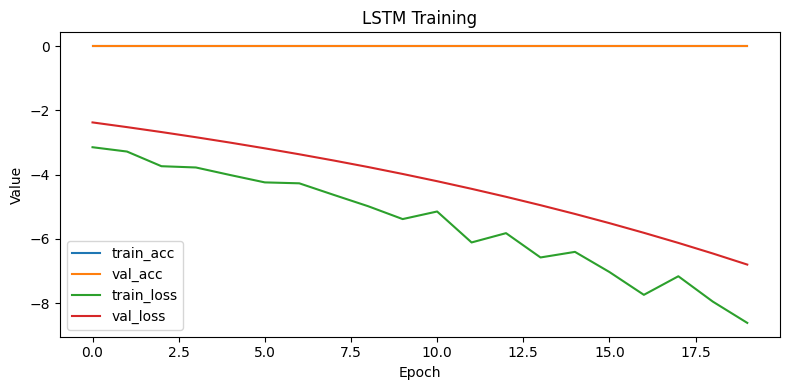

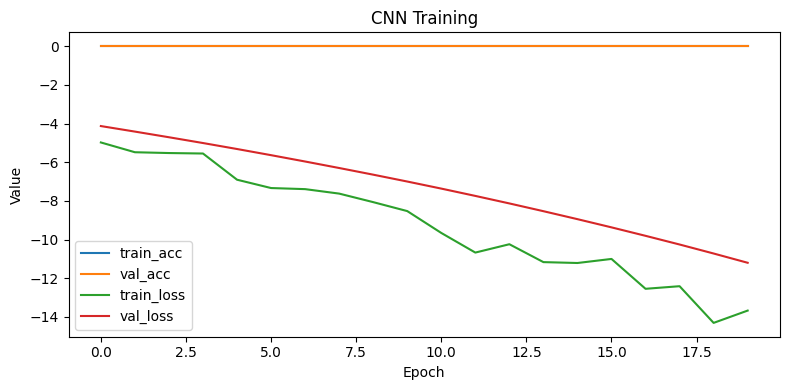

In [35]:
# =========================
# 5. Plot Training Curves
# =========================
def plot_history(history, title, out_file):
    plt.figure(figsize=(8,4))
    plt.plot(history.history["accuracy"], label="train_acc")
    plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_file)
    plt.show()

plot_history(history_lstm, "LSTM Training", results_dir / "lstm_training_curve.png")
plot_history(history_cnn, "CNN Training", results_dir / "cnn_training_curve.png")

In [36]:
# =====================================================
# 03. Table 5: Sequence Model Performance (Extended Metrics)
# =====================================================

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# -----------------------------------------------------
# Get predictions for test set
# -----------------------------------------------------
y_prob_lstm = lstm_model.predict(X_test).ravel()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

y_prob_cnn = cnn_model.predict(X_test).ravel()
y_pred_cnn = (y_prob_cnn > 0.5).astype(int)

# -----------------------------------------------------
# Evaluate models on test set
# -----------------------------------------------------
lstm_eval = lstm_model.evaluate(X_test, y_test, verbose=0)
cnn_eval  = cnn_model.evaluate(X_test, y_test, verbose=0)

# -----------------------------------------------------
# Helper: safe metric calculation
# -----------------------------------------------------
def compute_metrics(model_name, eval_results, y_true, y_pred, y_prob):
    # Decide averaging strategy
    avg_setting = "binary" if len(np.unique(y_true)) == 2 else "weighted"
    
    # Safe ROC AUC
    roc_auc = None
    if len(np.unique(y_true)) > 1:
        try:
            roc_auc = roc_auc_score(y_true, y_prob)
        except Exception:
            roc_auc = None
    
    return {
        "Model": model_name,
        "Loss": eval_results[0],
        "Accuracy": eval_results[1],
        "Precision": precision_score(y_true, y_pred, average=avg_setting, zero_division=0),
        "Recall": recall_score(y_true, y_pred, average=avg_setting, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average=avg_setting, zero_division=0),
        "ROC AUC": roc_auc
    }

# -----------------------------------------------------
# Compute metrics for each model
# -----------------------------------------------------
lstm_metrics = compute_metrics("LSTM", lstm_eval, y_test, y_pred_lstm, y_prob_lstm)
cnn_metrics  = compute_metrics("CNN",  cnn_eval,  y_test, y_pred_cnn,  y_prob_cnn)

# -----------------------------------------------------
# Build Table 5 (Extended)
# -----------------------------------------------------
table5_ext = pd.DataFrame([lstm_metrics, cnn_metrics])

# Save to a new file (so we don't overwrite the simple one)
out_file = results_dir / "wesad_sequence_results_eval_extended.csv"
table5_ext.to_csv(out_file, index=False)

print("✅ Table 5 (Sequence Model Results - Extended Metrics) saved to:", out_file)
display(table5_ext)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
✅ Table 5 (Sequence Model Results - Extended Metrics) saved to: C:\Users\Sunil\Projects\HRV-GenAI\results\wesad_sequence_results_eval_extended.csv


,Model,Loss,Accuracy,Precision,Recall,F1-score,ROC AUC
0,LSTM,-6.797227,0.0,0.0,0.0,0.0,None
1,CNN,-11.198940,0.0,0.0,0.0,0.0,None


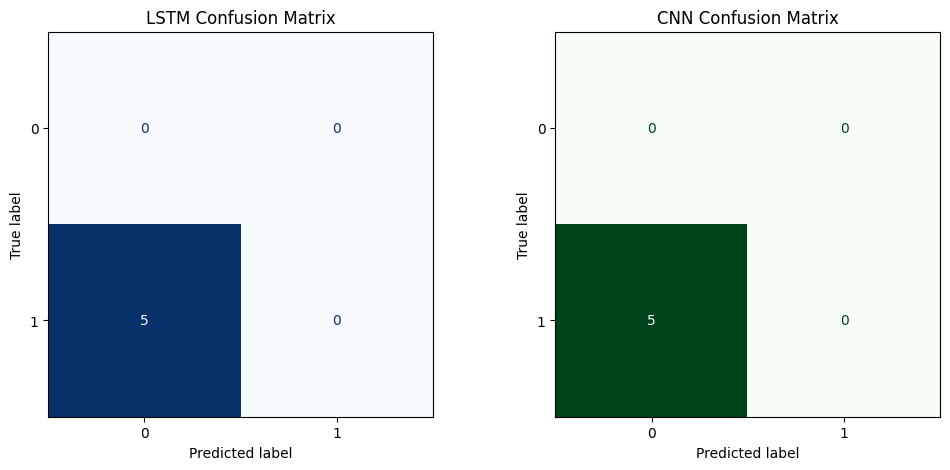

In [37]:
# =====================================================
# 11. Confusion Matrices
# =====================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12,5))

cm_lstm = confusion_matrix(y_test, y_pred_lstm)
ConfusionMatrixDisplay(cm_lstm).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("LSTM Confusion Matrix")

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
ConfusionMatrixDisplay(cm_cnn).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("CNN Confusion Matrix")

plt.show()